# Analyse exploratoire des données

## importation et apercu des données 

In [31]:
import sys 
print("Python version:", sys.version)

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [32]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd


In [34]:
# s'assurer que le moteur Excel est disponible
# exécuter une fois dans le notebook si nécessaire :


import pandas as pd




In [35]:
#lecture des fichiers Excel
file = "Customer_Churn_Data_Large.xlsx"
dem = pd.read_excel(file, sheet_name="Customer_Demographics")
trans = pd.read_excel(file, sheet_name="Transaction_History")
service = pd.read_excel(file, sheet_name="Customer_Service")
churn = pd.read_excel(file, sheet_name="Churn_Status")  
online = pd.read_excel(file, sheet_name="Online_Activity")

In [36]:
df = trans.merge(dem, on="CustomerID", how="left")

In [37]:
df = df.merge(service, on="CustomerID", how="left")

In [38]:
df = df.merge(churn, on="CustomerID", how="left")

In [39]:
df= df.merge(online, on="CustomerID", how="left")

In [40]:
df.head(10)

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory,Age,Gender,MaritalStatus,IncomeLevel,InteractionID,InteractionDate,InteractionType,ResolutionStatus,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage
0,1,7194,2022-03-27,416.50,Electronics,62,M,Single,Low,6363.0,2022-03-31,Inquiry,Resolved,0,2023-10-21,34,Mobile App
1,2,7250,2022-08-08,54.96,Clothing,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
2,2,9660,2022-07-25,197.50,Electronics,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
3,2,2998,2022-01-25,101.31,Furniture,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
4,2,1228,2022-07-24,397.37,Clothing,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
5,2,8903,2022-01-09,285.21,Electronics,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
6,2,3527,2022-09-16,311.34,Electronics,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
7,2,9279,2022-11-19,199.73,Groceries,65,M,Married,Low,3329.0,2022-03-17,Inquiry,Resolved,1,2023-12-05,5,Website
8,3,9839,2022-10-08,241.06,Books,18,M,Single,Low,9976.0,2022-08-24,Inquiry,Resolved,0,2023-11-15,3,Website
9,3,7364,2022-08-15,51.07,Clothing,18,M,Single,Low,9976.0,2022-08-24,Inquiry,Resolved,0,2023-11-15,3,Website


In [41]:
# stats descriptives sauf les dates ,costumerID, transactionID, ChurnStatus qui sont des identifiants et la variable cible 
df.describe(exclude=['datetime64', 'object'])

,CustomerID,TransactionID,AmountSpent,Age,InteractionID,ChurnStatus,LoginFrequency
count,6812.000000,6812.000000,6812.000000,6812.000000,5204.000000,6812.000000,6812.000000
mean,500.169260,5497.323253,251.620527,43.274516,5921.861261,0.198473,25.724310
std,286.704642,2584.768541,142.901693,15.286788,2332.331260,0.398880,14.062032
min,1.000000,1000.000000,5.180000,18.000000,2015.000000,0.000000,1.000000
25%,247.000000,3223.500000,127.100000,30.000000,3873.250000,0.000000,14.000000
50%,505.500000,5515.000000,251.845000,44.000000,5903.000000,0.000000,26.000000
75%,750.000000,7675.250000,375.280000,56.000000,7851.000000,0.000000,38.000000
max,1000.000000,9997.000000,499.860000,69.000000,9997.000000,1.000000,49.000000


## detection des anomalies 

In [42]:
#verification des doublons et leur pourcentage dans le dataset
duplicates = df.duplicated()
num_duplicates = duplicates.sum()
total_rows = len(df)
percentage_duplicates = (num_duplicates / total_rows) * 100
print(f"Nombre de doublons : {num_duplicates}")
print(f"Pourcentage de doublons : {percentage_duplicates:.2f}%")






Nombre de doublons : 0
Pourcentage de doublons : 0.00%


In [43]:
# detection des valeurs manquantes et leur pourcentage dans le dataset de chaque colonne
missing_values = df.isnull().sum()
total_rows = len(df)
percentage_missing = (missing_values / total_rows) * 100
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage Missing': percentage_missing
})
print(missing_data)


                  Missing Values  Percentage Missing
CustomerID                     0            0.000000
TransactionID                  0            0.000000
TransactionDate                0            0.000000
AmountSpent                    0            0.000000
ProductCategory                0            0.000000
Age                            0            0.000000
Gender                         0            0.000000
MaritalStatus                  0            0.000000
IncomeLevel                    0            0.000000
InteractionID               1608           23.605402
InteractionDate             1608           23.605402
InteractionType             1608           23.605402
ResolutionStatus            1608           23.605402
ChurnStatus                    0            0.000000
LastLoginDate                  0            0.000000
LoginFrequency                 0            0.000000
ServiceUsage                   0            0.000000


In [44]:
# verification des types de données 
print(df.dtypes)




CustomerID                   int64
TransactionID                int64
TransactionDate     datetime64[ns]
AmountSpent                float64
ProductCategory             object
Age                          int64
Gender                      object
MaritalStatus               object
IncomeLevel                 object
InteractionID              float64
InteractionDate     datetime64[ns]
InteractionType             object
ResolutionStatus            object
ChurnStatus                  int64
LastLoginDate       datetime64[ns]
LoginFrequency               int64
ServiceUsage                object
dtype: object


In [45]:
# valeurs uniques des variables catégorielles sauf interactiondate

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_values = df[col].unique()
    print(f"Colonne: {col}")
    print(f"Valeurs uniques: {unique_values}\n")


Colonne: ProductCategory
Valeurs uniques: ['Electronics' 'Clothing' 'Furniture' 'Groceries' 'Books']

Colonne: Gender
Valeurs uniques: ['M' 'F']

Colonne: MaritalStatus
Valeurs uniques: ['Single' 'Married' 'Widowed' 'Divorced']

Colonne: IncomeLevel
Valeurs uniques: ['Low' 'Medium' 'High']

Colonne: InteractionType
Valeurs uniques: ['Inquiry' nan 'Feedback' 'Complaint']

Colonne: ResolutionStatus
Valeurs uniques: ['Resolved' 'Unresolved' nan]

Colonne: ServiceUsage
Valeurs uniques: ['Mobile App' 'Website' 'Online Banking']



In [46]:
# les valeurs uniques de resolutionstatus et leur pourcentage dans le dataset
resolution_status_counts = df['ResolutionStatus'].value_counts()
resolution_status_percentage = df['ResolutionStatus'].value_counts(normalize=True) * 100
resolution_status_data = pd.DataFrame({
    'Count': resolution_status_counts,
    'Percentage': resolution_status_percentage
})
print(resolution_status_data)

                  Count  Percentage
ResolutionStatus                   
Resolved           2693   51.748655
Unresolved         2511   48.251345


In [47]:
# valeurs uniques de interactiontype
interaction_type_counts = df['InteractionType'].value_counts()
interaction_type_percentage = df['InteractionType'].value_counts(normalize=True) * 100
interaction_type_data = pd.DataFrame({
    'Count': interaction_type_counts,
    'Percentage': interaction_type_percentage
})  
print(interaction_type_data)

                 Count  Percentage
InteractionType                   
Feedback          1921   36.913912
Complaint         1769   33.993082
Inquiry           1514   29.093005


## exploration des donnees 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


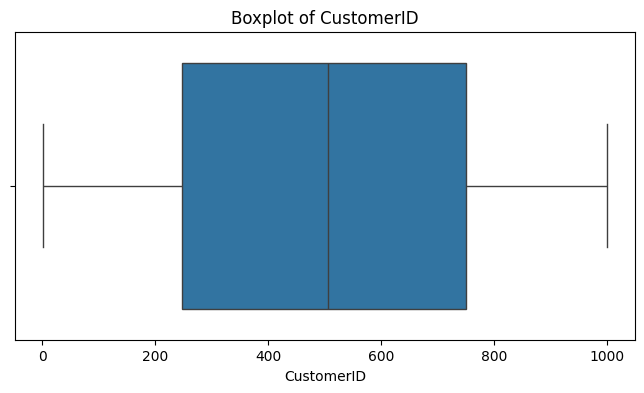

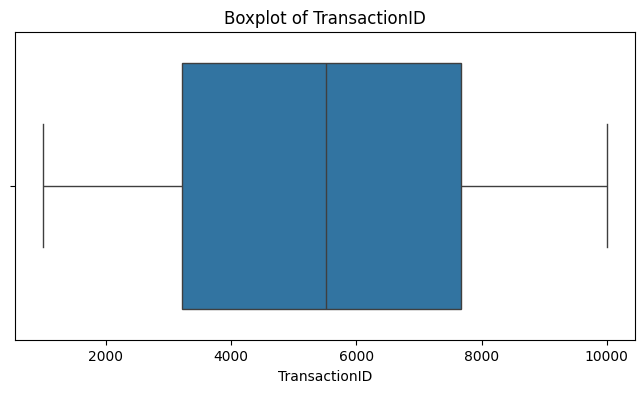

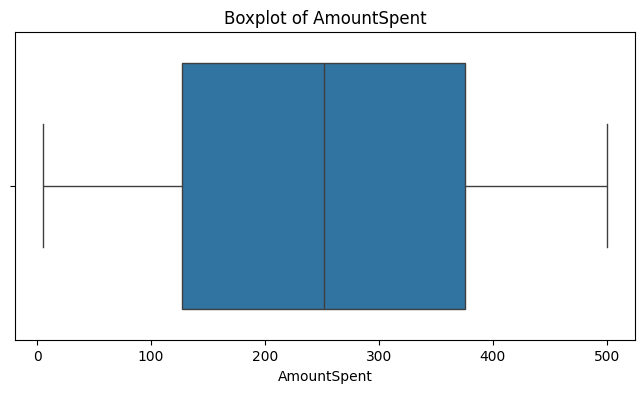

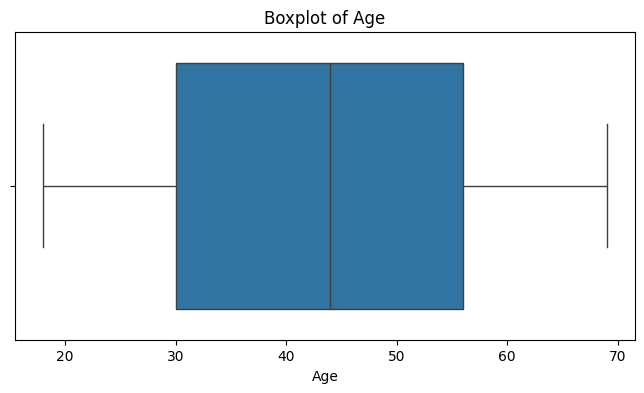

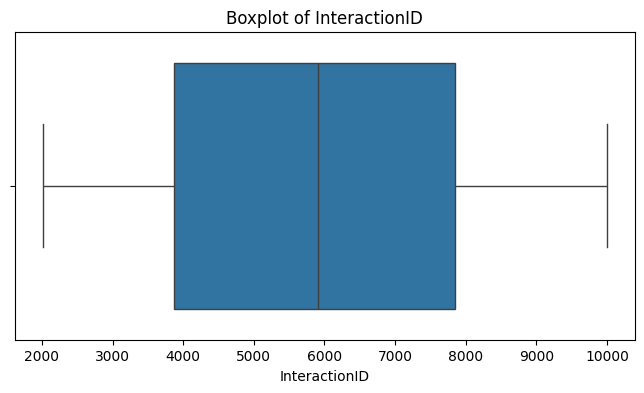

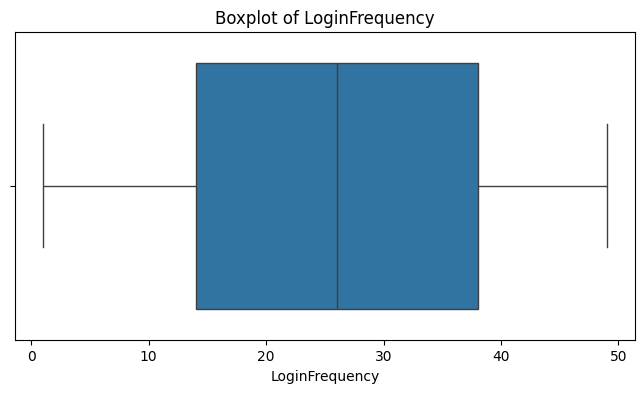

In [48]:
# distribution et verification des outliers avec les boxplots pour les variables numériques sans la variable cible "ChurnStatus"
%pip install matplotlib seaborn

import matplotlib.pyplot as plt 
import seaborn as sns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('ChurnStatus')
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

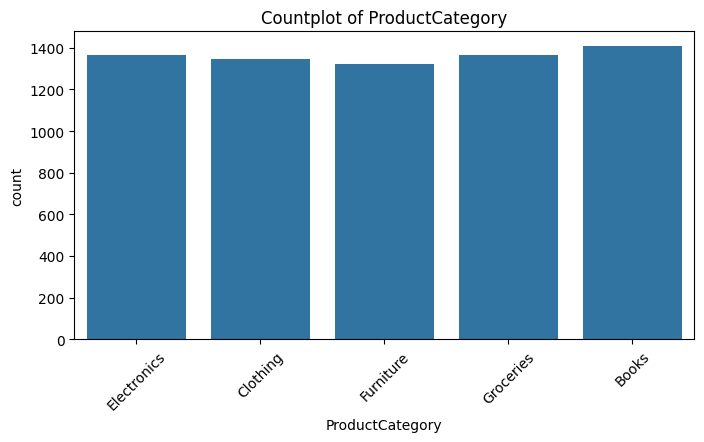

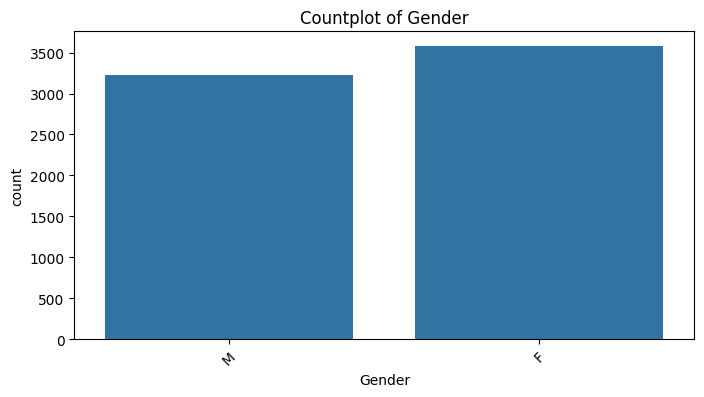

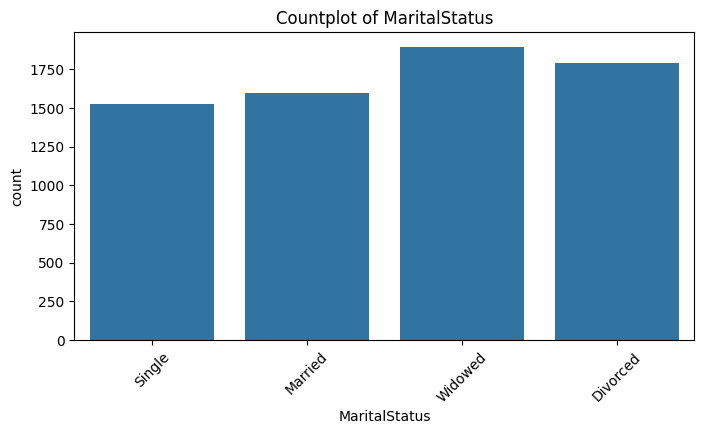

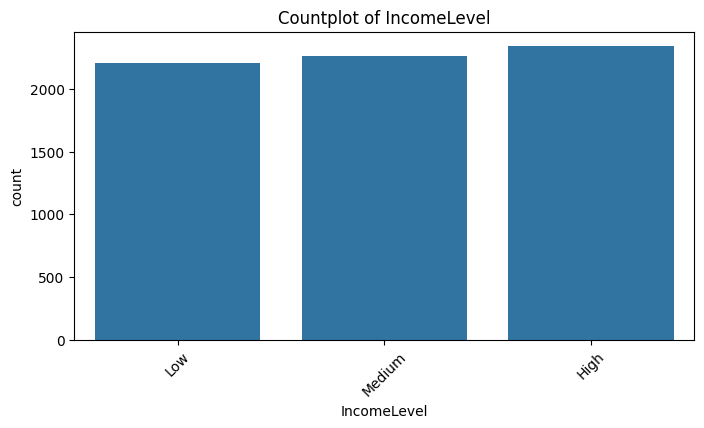

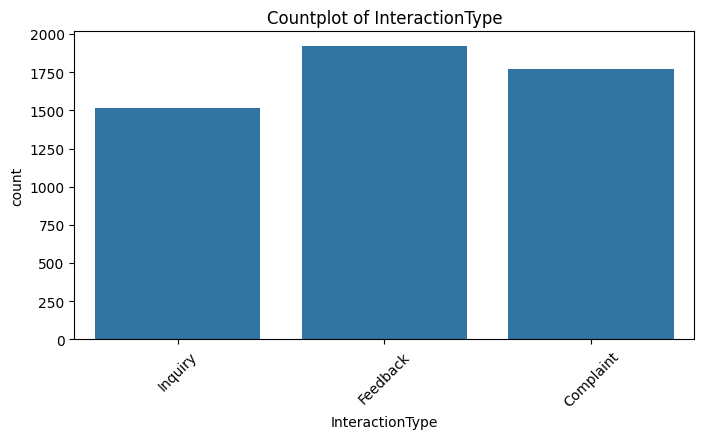

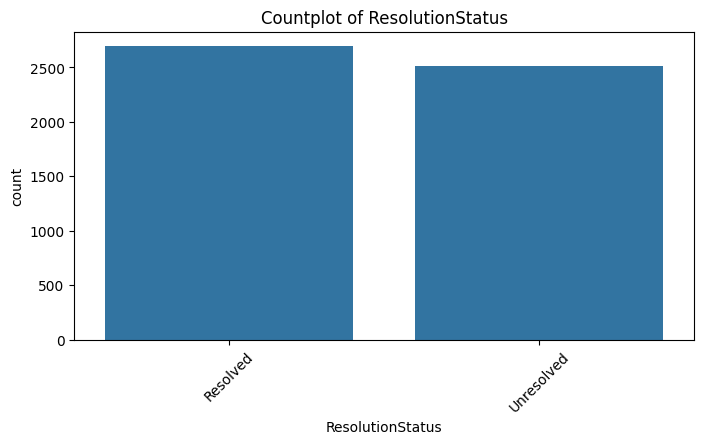

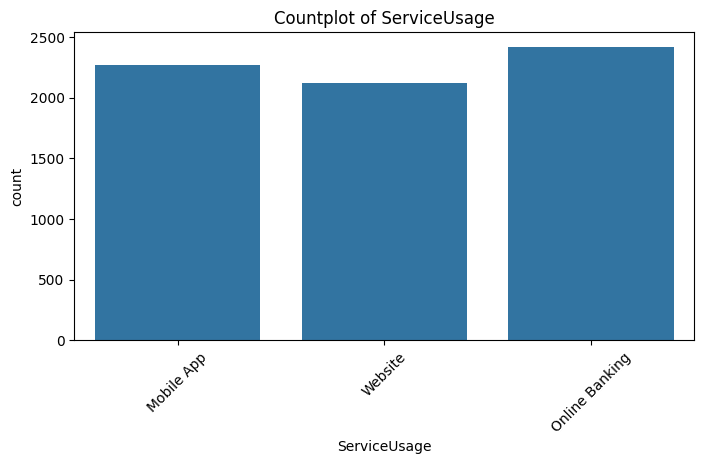

In [49]:
# distribution des variables catégorielles
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()

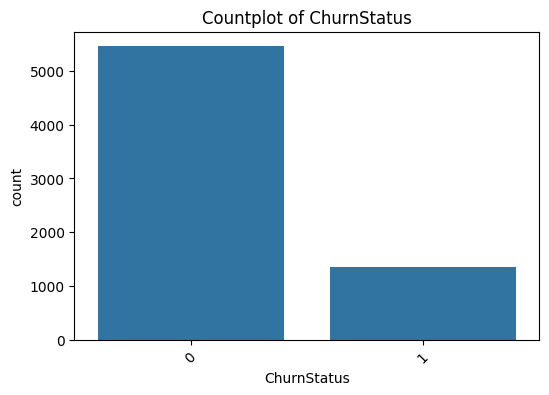

In [50]:
# distribution de la variable cible "ChurnStatus"
plt.figure(figsize=(6, 4))
sns.countplot(x=df['ChurnStatus'])
plt.title('Countplot of ChurnStatus')
plt.xticks(rotation=45)
plt.show()


Text(0.5, 1.0, 'Correlation Matrix of Numerical Variables')

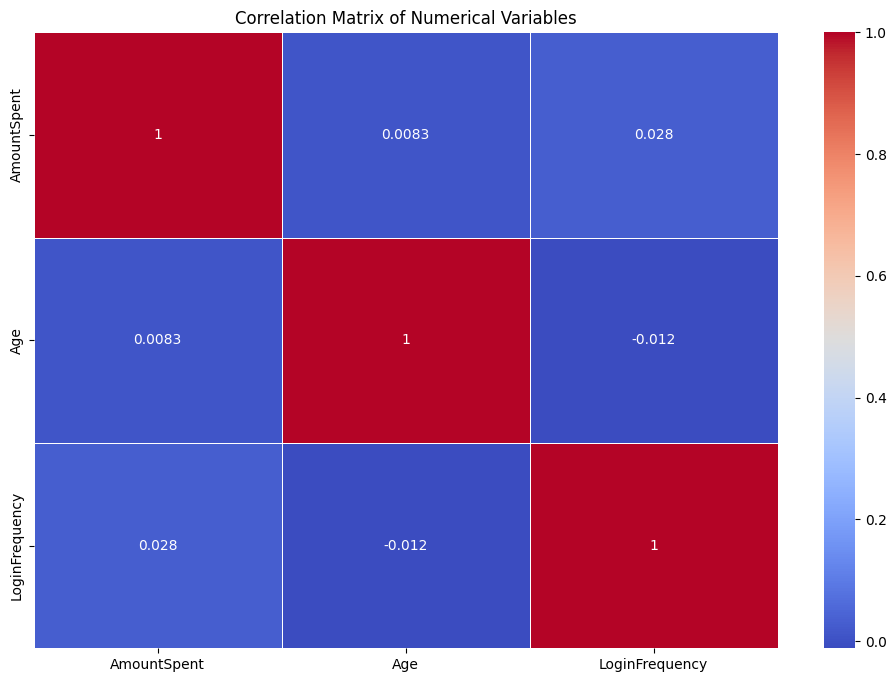

In [51]:
# matrice de correlation pour les variables numeriques sauf costumerID, transactionID qui sont des identifiants et la variable cible
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['CustomerID', 'TransactionID', 'InteractionID', 'ChurnStatus'])
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')


In [52]:
# tableau de contigence entre les variables catégorielles et la variable cible "ChurnStatus"
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['ChurnStatus'])
    print(f"Contingency Table for {col} and ChurnStatus:")
    print(contingency_table)
    print("\n")
    

Contingency Table for ProductCategory and ChurnStatus:
ChurnStatus         0    1
ProductCategory           
Books            1146  262
Clothing         1096  252
Electronics      1064  302
Furniture        1053  271
Groceries        1101  265


Contingency Table for Gender and ChurnStatus:
ChurnStatus     0    1
Gender                
F            2924  656
M            2536  696


Contingency Table for MaritalStatus and ChurnStatus:
ChurnStatus       0    1
MaritalStatus           
Divorced       1458  335
Married        1258  337
Single         1196  332
Widowed        1548  348


Contingency Table for IncomeLevel and ChurnStatus:
ChurnStatus     0    1
IncomeLevel           
High         1940  400
Low          1730  477
Medium       1790  475


Contingency Table for InteractionType and ChurnStatus:
ChurnStatus         0    1
InteractionType           
Complaint        1399  370
Feedback         1523  398
Inquiry          1210  304


Contingency Table for ResolutionStatus and ChurnS

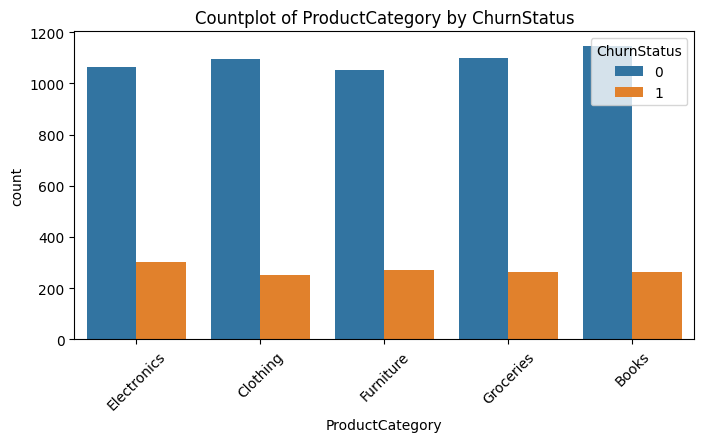

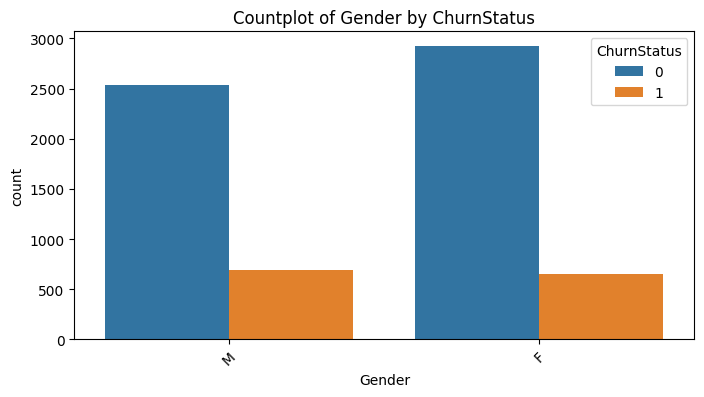

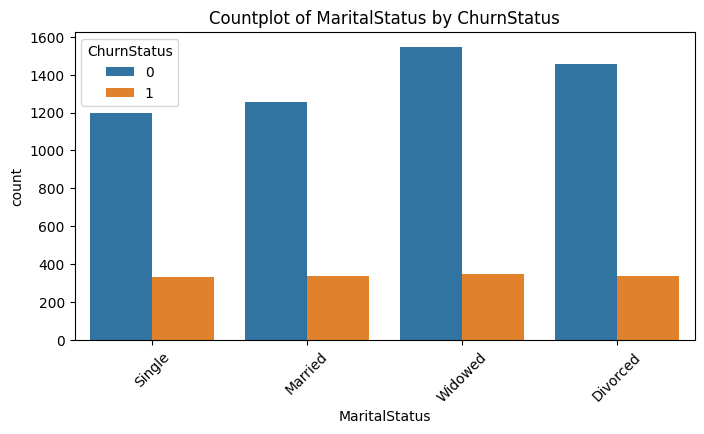

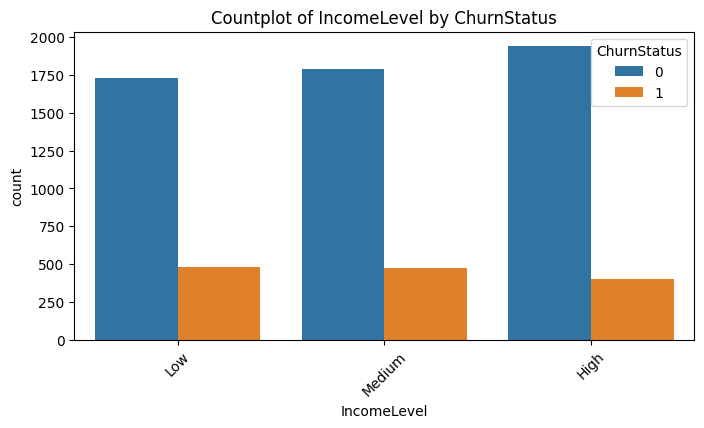

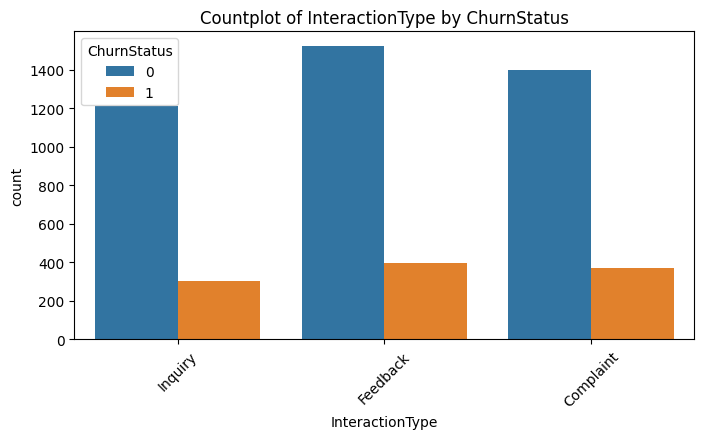

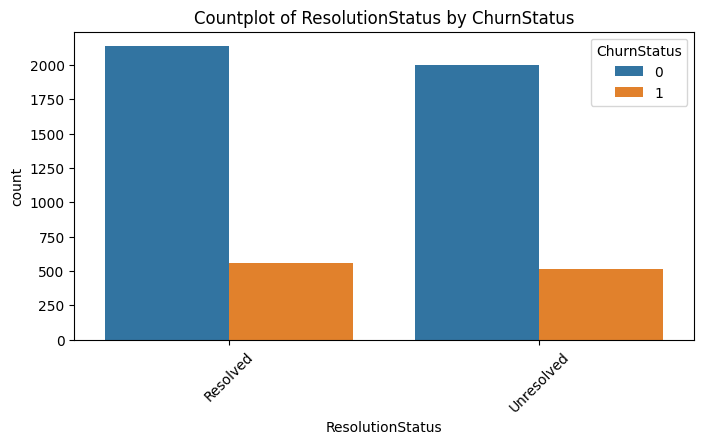

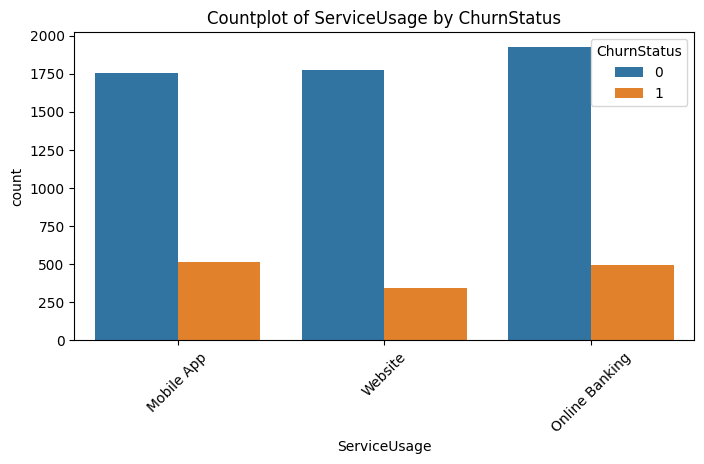

In [53]:
#tableau de distribution des variables catégorielles par rapport à la variable cible "ChurnStatus"
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col], hue=df['ChurnStatus'])
    plt.title(f'Countplot of {col} by ChurnStatus')
    plt.xticks(rotation=45)
    plt.legend(title='ChurnStatus')
    plt.show()

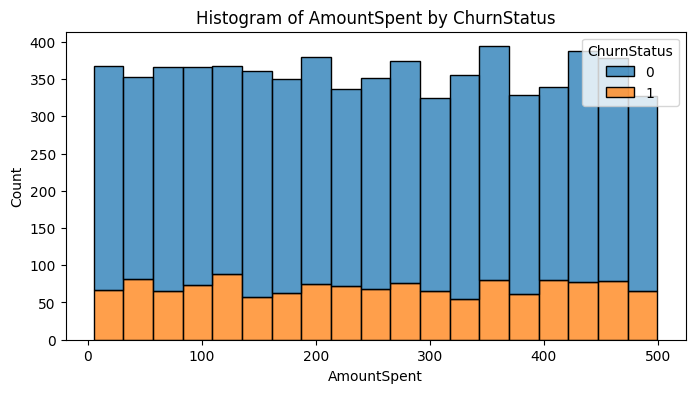

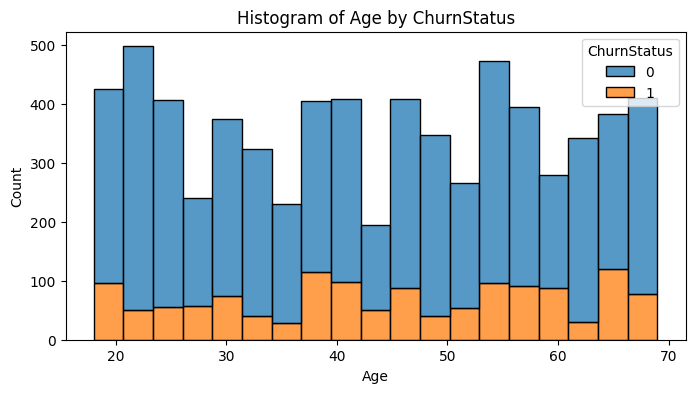

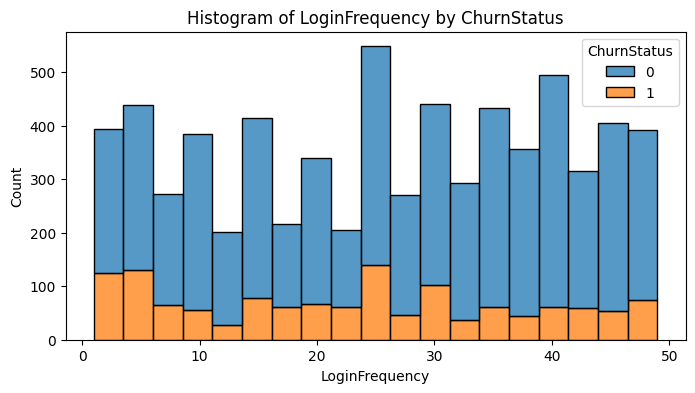

In [54]:
# relation entre les variables numeriques et la variable cible "ChurnStatus" avec des histogrammes
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=df[col], hue=df['ChurnStatus'], multiple='stack')
    plt.title(f'Histogram of {col} by ChurnStatus')
    plt.show()

<Axes: xlabel='Month', ylabel='count'>

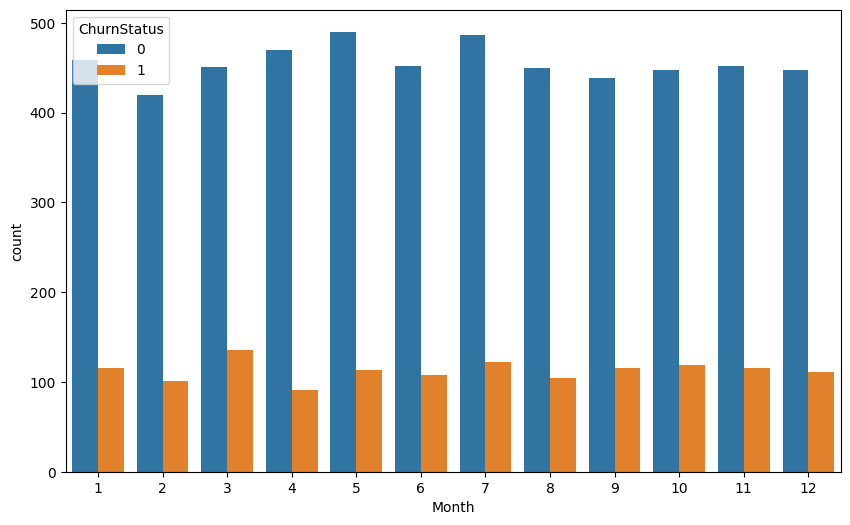

In [55]:
# graphique montrant les mois de l'année et le nombre de clients qui ont churné ou pas pour voir s'il y a une saisonnalité dans le churn
df['Month'] = df['TransactionDate'].dt.month
plt.figure(figsize=(10, 6))
sns.countplot(x=df['Month'], hue=df['ChurnStatus'])



In [56]:
# verification des lignes avec des valeurs manquantes
missing_rows = df[df.isnull().any(axis=1)]
missing_rows.head(20)

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory,Age,Gender,MaritalStatus,IncomeLevel,InteractionID,InteractionDate,InteractionType,ResolutionStatus,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage,Month
24,5,1742,2022-02-21,475.69,Groceries,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,2
25,5,9349,2022-08-12,178.91,Furniture,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,8
26,5,7200,2022-12-02,373.51,Groceries,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,12
27,5,4938,2022-10-21,155.76,Electronics,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,10
28,5,5357,2022-07-04,308.80,Electronics,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,7
29,5,6791,2022-08-31,219.98,Furniture,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,8
30,5,7592,2022-12-21,218.98,Electronics,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,12
31,5,9249,2022-05-25,69.86,Groceries,21,M,Divorced,Medium,NaN,NaT,NaN,NaN,0,2023-10-27,41,Website,5
37,7,8762,2022-10-24,86.73,Books,27,F,Married,High,NaN,NaT,NaN,NaN,0,2023-01-07,32,Mobile App,10
57,10,3487,2022-09-07,5.86,Furniture,68,M,Married,High,NaN,NaT,NaN,NaN,1,2023-01-13,29,Online Banking,9


# Nettoyage et pretraitement 

on observe dans l'ensemble des données des valeurs manquantes . Cependant le dataset est quasi propre c'est a dire zero valeur manquante , pas de doublons , pas d'outliers etc. 
On note aussi l'ensemble des données dans chaque variable une distribution uniforme a part que la variable cible est tres déséquilibrée. Dans les etapes qui vont suivre nous tenterons de normaliser cette deniere avant l'etape de la modelisation . 

In [57]:
# suppression des variables unitiles dont les ID et les dates
df.drop(columns=['CustomerID', 'TransactionID', 'InteractionID', 'TransactionDate'], inplace=True)

In [58]:
# remplacer les valeurs nulles par 'missing values'
df.fillna('missing values', inplace=True)
# verification du remplacement des valeurs manquantes
missing_values_after = df.isnull().sum()
print(missing_values_after)

AmountSpent         0
ProductCategory     0
Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
ChurnStatus         0
LastLoginDate       0
LoginFrequency      0
ServiceUsage        0
Month               0
dtype: int64


C:\Users\samba\AppData\Local\Temp\ipykernel_45636\2620199703.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'missing values' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna('missing values', inplace=True)


In [59]:
# pretraitement
#Separation train test
from sklearn.model_selection import train_test_split
X = df.drop('ChurnStatus', axis=1)
y = df['ChurnStatus']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
#distinction des variables nominales et ordinales pour le pretraitement
nom=['ProductCategory','Gender','MaritalStatus','InteractionType','ResolutionStatus','ServiceUsage']
ord=['IncomeLevel']
num=['Age','AmountSpent','LoginFrequency']

In [61]:
# preprocessing
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder  
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num),
    ('nom', OneHotEncoder(), nom),
    ('ord', OrdinalEncoder(), ord)
])

In [64]:


# pipeline complet avec trois modeles de classification pour comparer les resultats
from imblearn.pipeline import Pipeline  # pipeline compatible SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

pipelines = {
    "LR": Pipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    "RF": Pipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "SVM": Pipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', SVC(probability=True, random_state=42))
    ])
}



In [65]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring='f1'   
    )
    cv_results[name] = scores.mean()
    print(f"{name} - F1 moyen (CV): {scores.mean():.4f}")
    
    



LR - F1 moyen (CV): 0.3479
RF - F1 moyen (CV): 0.8162
SVM - F1 moyen (CV): 0.6169


In [66]:
for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring='recall'   
    )
    cv_results[name] = scores.mean()
    print(f"{name} - Recall moyen (CV): {scores.mean():.4f}")

LR - Recall moyen (CV): 0.5536
RF - Recall moyen (CV): 0.7100
SVM - Recall moyen (CV): 0.6855


In [67]:
for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'   
    )
    cv_results[name] = scores.mean()
    print(f"{name} - Accuracy moyen (CV): {scores.mean():.4f}")

LR - Accuracy moyen (CV): 0.5812
RF - Accuracy moyen (CV): 0.9356
SVM - Accuracy moyen (CV): 0.8282


In [69]:
# réglage des hyperparamètres pour le modèle RandomForest via GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10]
}

rf_pipe = pipelines['RF']
# inclure preprocessing et smote
# utiliser n_jobs=2 pour éviter la surcharge mémoire avec n_jobs=-1
search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='f1', n_jobs=2, verbose=1)
search.fit(X_train, y_train)

print("Meilleurs paramètres RF:", search.best_params_)
print("Meilleur F1 (CV):", search.best_score_)

# remplacer la pipeline RF existante par la meilleure trouvée
pipelines['RF'] = search.best_estimator_


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Meilleurs paramètres RF: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Meilleur F1 (CV): 0.8161980409253344


In [70]:
best_model_name = max(cv_results, key=cv_results.get)
best_pipeline = pipelines["RF"]

print("\nMeilleur modèle (sur le train / CV) :", best_model_name)


Meilleur modèle (sur le train / CV) : RF


In [71]:
best_pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The gi

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n=== Performance sur le test avec le meilleur modèle ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")


=== Performance sur le test avec le meilleur modèle ===
Accuracy : 0.9435
Precision: 0.9353
Recall   : 0.7460
F1       : 0.8300
AUC-ROC  : 0.9853


Text(0.5, 1.0, 'Confusion Matrix')

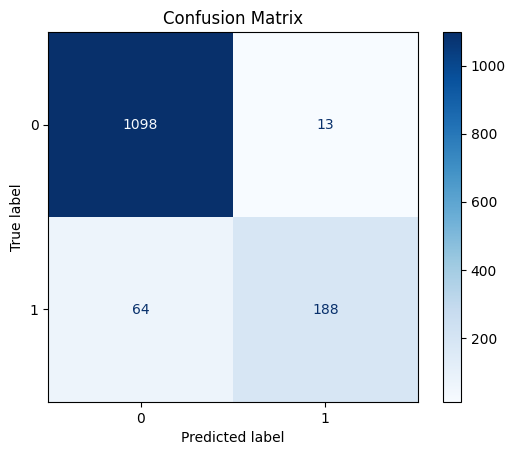

In [73]:
# matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipeline.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')


Top 20 features importantes :
LoginFrequency                     0.171680
Age                                0.158949
AmountSpent                        0.081277
ServiceUsage_Website               0.068528
ProductCategory_Clothing           0.034860
IncomeLevel                        0.034297
ProductCategory_Furniture          0.031877
ProductCategory_Books              0.031786
ProductCategory_Electronics        0.029188
Gender_M                           0.027261
MaritalStatus_Single               0.027091
ServiceUsage_Online Banking        0.026260
MaritalStatus_Married              0.025902
ResolutionStatus_missing values    0.025817
ServiceUsage_Mobile App            0.025205
MaritalStatus_Divorced             0.024959
InteractionType_missing values     0.022806
InteractionType_Complaint          0.022258
MaritalStatus_Widowed              0.022047
Gender_F                           0.021915
dtype: float64


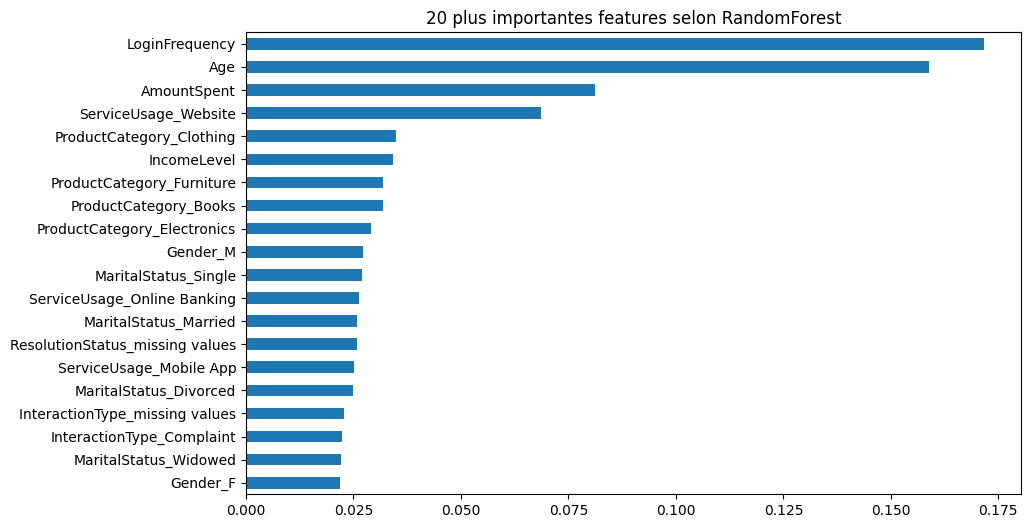

In [74]:
# identification des features importantes du modèle RandomForest
# le modèle est stocké dans le step 'model' du pipeline
tree = best_pipeline.named_steps['model']
preproc = best_pipeline.named_steps['prep']

# reconstruire la liste des noms de features après preprocessing
num_features = num
ord_features = ord
nom_encoder = preproc.named_transformers_['nom']
nominal_features = nom_encoder.get_feature_names_out(nom)
all_features = list(num_features) + list(ord_features) + list(nominal_features)

importances = tree.feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

print("Top 20 features importantes :")
print(feat_imp.head(20))

# plot bar chart
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
feat_imp.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('20 plus importantes features selon RandomForest')
plt.show()

In [76]:
import joblib
joblib.dump(best_pipeline, "model.pkl")

['model.pkl']